# YOLOE → Any6D Pipeline

**Ce notebook utilise exactement votre code YOLOE existant et branche la sortie dans Any6D.**

```
refer_image (anchor) + test_image (scene)
           ↓
    YOLOE visual prompt
           ↓
   results[0].masks  ← ob_mask
           ↓
   Any6D.register_any6d(K, rgb, depth, ob_mask)
           ↓
   Pose 4×4
```

> Run this notebook in **master_env** (YOLOE) — Any6D is called via Docker subprocess.

## Cell 1 — YOLOE imports 

In [1]:
import sys
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor

print(f'Python:  {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

Python:  3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
PyTorch: 2.11.0+cu130
CUDA:    True
GPU:     NVIDIA L4


## Cell 2 — Config paths

In [2]:
# ── Paths ─────────────────────────────────────────────────────
REFER_IMAGE_PATH = "/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg"  # anchor
TEST_IMAGE_PATH  = "/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg"  # scene
DEPTH_IMAGE_PATH = "/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/depth.png"       # depth 16-bit

# Any6D paths (inside Docker container = /workspace)
MESH_PATH        = "/workspace/demo_data/mustard.obj"
MASK_SAVE_PATH   = "/tmp/yoloe_mask.npy"       # shared between host and container
RESULTS_PATH     = "/tmp/any6d_results"

# Camera intrinsics — adjust to your camera
K = np.array([
    [614.0,   0.0, 320.0],
    [  0.0, 614.0, 240.0],
    [  0.0,   0.0,   1.0]
], dtype=np.float64)

DEPTH_SCALE = 1000.0  # mm → meters

print('Paths configured')
print(f'  Anchor: {REFER_IMAGE_PATH}')
print(f'  Scene:  {TEST_IMAGE_PATH}')

Paths configured
  Anchor: /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg
  Scene:  /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg


## Cell 3 — YOLOE: visual prompt detection 

Running YOLOE...
Ultralytics 8.4.41 🚀 Python-3.10.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOe-26l-seg summary (fused): 232 layers, 35,437,026 parameters, 2,749,490 gradients, 141.6 GFLOPs

image 1/1 /home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg: 640x480 3 object0s, 23.7ms
Speed: 2.7ms preprocess, 23.7ms inference, 14.0ms postprocess per image at shape (1, 3, 640, 480)
Found 3 matching objects


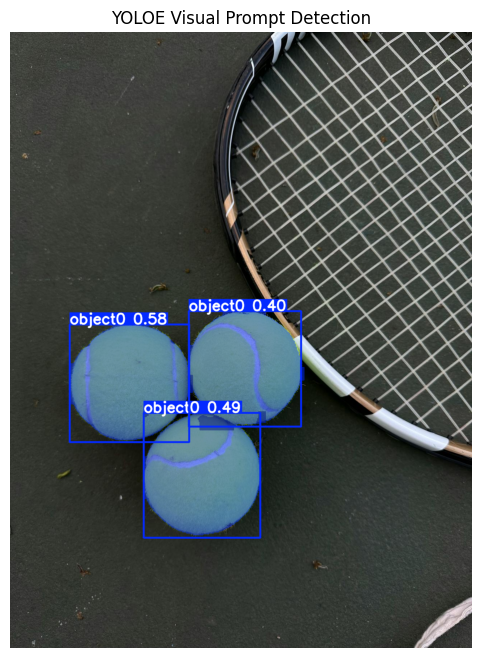

In [4]:
# ── Load model (votre code) ───────────────────────────────────
model = YOLOE("yoloe-26l-seg.pt")

# ── Load anchor image (votre code) ───────────────────────────
url = "https://images.pexels.com/photos/13025827/pexels-photo-13025827.jpeg" #"https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
refer_image = Image.open(BytesIO(response.content))
refer_image.save("test_image.jpg")
test_image  = r"/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res.jpg"

# refer_image = Image.open(REFER_IMAGE_PATH)
w_ref, h_ref = refer_image.size

# ── Visual prompt (votre code) ────────────────────────────────
# bbox dans l'image anchor pointant vers l'objet
visual_prompts = {
    "cls": [0],
    "bboxes": [[2317, 2084, 4353, 4076]]  # ← ajustez selon votre objet
    # Ou utilisez tout l'anchor: [[0, 0, w_ref, h_ref]]
}

# ── Run YOLOE (votre code) ────────────────────────────────────
print('Running YOLOE...')
results = model.predict(
    TEST_IMAGE_PATH,
    refer_image=refer_image,
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor
)

print(f'Found {len(results[0].boxes)} matching objects')

# ── Visualize (votre code) ────────────────────────────────────
result = results[0]
annotated = result.plot()
plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1])
plt.title('YOLOE Visual Prompt Detection')
plt.axis('off')
plt.show()

## Cell 4 — Extract mask from YOLOE → save for Any6D

Best detection: bbox=[ 165  810  496 1136], conf=0.575
Segmentation mask: 84570 pixels
Saved mask → /tmp/yoloe_mask.npy


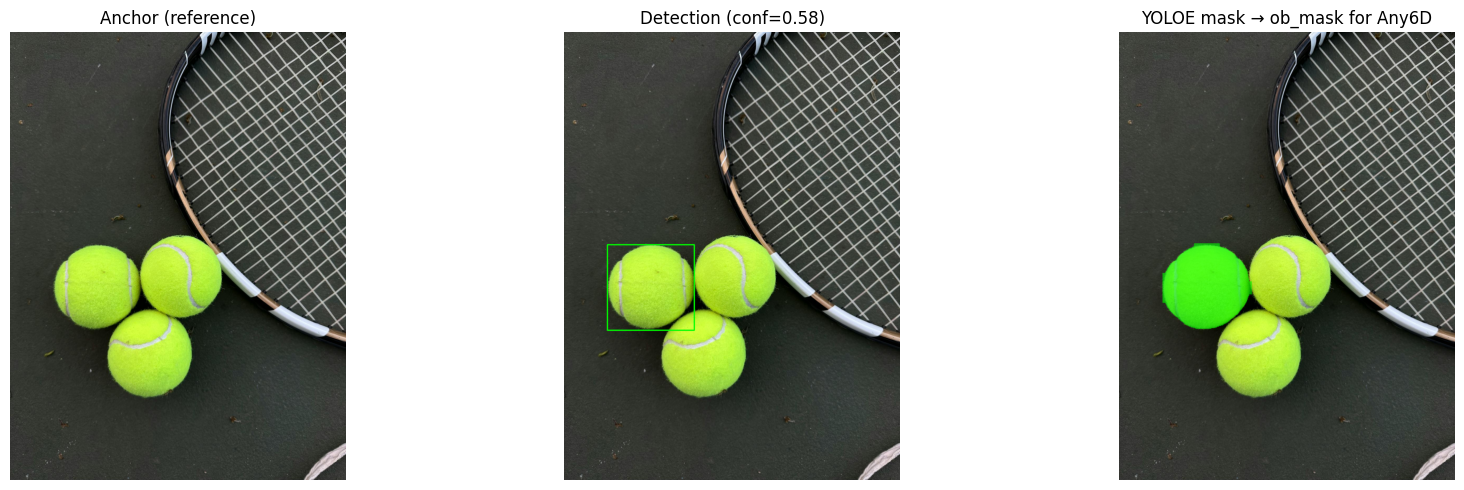

In [5]:
result = results[0]

if len(result.boxes) == 0:
    raise ValueError('No object detected! Adjust visual_prompts bbox.')

# ── Best detection ────────────────────────────────────────────
best_idx  = result.boxes.conf.argmax().item()
bbox_xyxy = result.boxes.xyxy[best_idx].cpu().numpy().astype(int)
conf      = result.boxes.conf[best_idx].item()
print(f'Best detection: bbox={bbox_xyxy}, conf={conf:.3f}')

# ── Load scene image ──────────────────────────────────────────
scene_bgr = cv2.imread(TEST_IMAGE_PATH)
scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
H, W = scene_rgb.shape[:2]

# ── Extract ob_mask (same format as run_demo.py) ──────────────
# run_demo.py: mask = np.where(label['seg'] == obj_num, 255, 0).astype(np.bool_)
if result.masks is not None:
    raw_mask = result.masks.data[best_idx].cpu().numpy()
    raw_mask = cv2.resize(raw_mask, (W, H))
    ob_mask  = (raw_mask > 0.5).astype(np.bool_)
    print(f'Segmentation mask: {ob_mask.sum()} pixels')
else:
    # fallback: bbox mask
    ob_mask = np.zeros((H, W), dtype=np.bool_)
    x1, y1, x2, y2 = bbox_xyxy
    ob_mask[y1:y2, x1:x2] = True
    print('No segmentation — using bbox mask')

# ── Save mask + scene for Any6D ───────────────────────────────
import os
os.makedirs(RESULTS_PATH, exist_ok=True)
np.save(MASK_SAVE_PATH, ob_mask)
np.save('/tmp/yoloe_K.npy', K)
cv2.imwrite('/tmp/yoloe_scene_rgb.png', cv2.cvtColor(scene_rgb, cv2.COLOR_RGB2BGR))
print(f'Saved mask → {MASK_SAVE_PATH}')

# ── Visualize mask ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(Image.open(REFER_IMAGE_PATH))
axes[0].set_title('Anchor (reference)')
axes[0].axis('off')

scene_box = scene_rgb.copy()
x1, y1, x2, y2 = bbox_xyxy
cv2.rectangle(scene_box, (x1,y1), (x2,y2), (0,255,0), 3)
axes[1].imshow(scene_box)
axes[1].set_title(f'Detection (conf={conf:.2f})')
axes[1].axis('off')

mask_vis = scene_rgb.copy()
mask_vis[ob_mask] = (mask_vis[ob_mask]*0.4 + np.array([0,255,0])*0.6).astype(np.uint8)
axes[2].imshow(mask_vis)
axes[2].set_title('YOLOE mask → ob_mask for Any6D')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Cell 5 — Any6D: run pose estimation with YOLOE mask

In [10]:

script = open('/tmp/any6d_run.py', 'w')
script.write('import sys, os\n')
script.write('import numpy as np\n')
script.write('import cv2\n')
script.write('import trimesh\n')
script.write('sys.path.insert(0, "/workspace")\n')
script.write('sys.path.insert(0, "/workspace/foundationpose/mycpp/build")\n')
script.write('import nvdiffrast.torch as dr\n')
script.write('from estimater import Any6D\n')
script.write('from pytorch_lightning import seed_everything\n')
script.write('seed_everything(0)\n')
script.write('glctx = dr.RasterizeCudaContext()\n')
script.write('ob_mask = np.load("/tmp/yoloe_mask.npy")\n')
script.write('scene_bgr = cv2.imread("/tmp/yoloe_scene_rgb.png")\n')
script.write('scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)\n')
script.write('depth = np.load("/tmp/yoloe_depth.npy")\n')
script.write('K = np.load("/tmp/yoloe_K.npy")\n')
script.write('print("ob_mask:", ob_mask.sum())\n')
script.write('mesh = trimesh.load("/workspace/demo_data/mustard.obj")\n')
script.write('os.makedirs("/tmp/any6d_results", exist_ok=True)\n')
script.write('est = Any6D(symmetry_tfs=None, mesh=mesh, debug_dir="/tmp/any6d_results", debug=0)\n')
script.write('pred_pose = est.register_any6d(K=K, rgb=scene_rgb, depth=depth, ob_mask=ob_mask, iteration=5, name="yoloe_any6d")\n')
script.write('np.save("/tmp/any6d_pose.npy", pred_pose)\n')
script.write('t = pred_pose[:3, 3]\n')
script.write('print("POSE:", pred_pose)\n')
script.write('print("Z:", round(float(t[2])*100, 1), "cm")\n')
script.close()
print('Script saved to /tmp/any6d_run.py')

Script saved to /tmp/any6d_run.py


In [11]:
import subprocess

cmd = [
    'docker', 'compose', 'run', '--rm',
    '-v', '/tmp:/tmp',
    'any6d',
    '/bin/bash', '--login', '-c',
    'python /tmp/any6d_run.py'
]

result_proc = subprocess.run(
    cmd,
    cwd='/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D',
    capture_output=True,
    text=True,
    timeout=300
)

print(result_proc.stdout)
if result_proc.returncode != 0:
    print('STDERR:', result_proc.stderr[-2000:])

TimeoutExpired: Command '['docker', 'compose', 'run', '--rm', '-v', '/tmp:/tmp', 'any6d', '/bin/bash', '--login', '-c', 'python /tmp/any6d_run.py']' timed out after 300 seconds

In [9]:
import subprocess

# ── Load depth ────────────────────────────────────────────────
depth = cv2.imread(DEPTH_IMAGE_PATH, cv2.IMREAD_ANYDEPTH)
if depth is None:
    # create fake depth if no depth image available
    print('WARNING: No depth image — using fake depth (1m everywhere)')
    depth = np.ones((H, W), dtype=np.float32) * DEPTH_SCALE
depth_m = depth.astype(np.float32) / DEPTH_SCALE
np.save('/tmp/yoloe_depth.npy', depth_m)

# ── Any6D script to run inside Docker container ───────────────
any6d_script = '''
import sys, os
import numpy as np
import cv2
import trimesh

sys.path.insert(0, "/workspace")
sys.path.insert(0, "/workspace/foundationpose")
sys.path.insert(0, "/workspace/foundationpose/mycpp/build")

import nvdiffrast.torch as dr
from estimater import Any6D
from pytorch_lightning import seed_everything

seed_everything(0)
glctx = dr.RasterizeCudaContext()

# Load inputs from YOLOE
ob_mask  = np.load("/tmp/yoloe_mask.npy")
scene_bgr = cv2.imread("/tmp/yoloe_scene_rgb.png")
scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
depth    = np.load("/tmp/yoloe_depth.npy")
K        = np.load("/tmp/yoloe_K.npy")

print(f"ob_mask pixels: {ob_mask.sum()}")
print(f"scene: {scene_rgb.shape}")
print(f"depth: {depth.shape}, range [{depth.min():.2f}, {depth.max():.2f}]")

# Load mesh
mesh = trimesh.load("/workspace/demo_data/mustard.obj")
print(f"mesh: {len(mesh.vertices)} vertices")

# Initialize Any6D
os.makedirs("/tmp/any6d_results", exist_ok=True)
est = Any6D(
    symmetry_tfs=None,
    mesh=mesh,
    debug_dir="/tmp/any6d_results",
    debug=2
)

# Run pose estimation with YOLOE mask
pred_pose = est.register_any6d(
    K=K,
    rgb=scene_rgb,
    depth=depth,
    ob_mask=ob_mask,
    iteration=5,
    name="yoloe_any6d"
)

# Save pose
np.save("/tmp/any6d_pose.npy", pred_pose)
np.savetxt("/tmp/any6d_pose.txt", pred_pose)

t = pred_pose[:3, 3]
print("\n=== POSE RESULT ===")
print(pred_pose)
print(f"\nPosition: X={t[0]*100:.1f}cm, Y={t[1]*100:.1f}cm, Z={t[2]*100:.1f}cm")
'''

# Save script
with open('/tmp/any6d_run.py', 'w') as f:
    f.write(any6d_script)

print('Running Any6D inside Docker container...')
print('This may take 1-2 minutes on first run...')

# Run inside Docker container
# Remplacez cmd par :
cmd = [
    'docker', 'compose', 'run', '--rm',
    '-v', '/tmp:/tmp',
    'any6d',
    '/bin/bash', '--login', '-c',
    'python /tmp/any6d_run.py'
]

result_proc = subprocess.run(
    cmd,
    cwd='/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D',
    capture_output=True,
    text=True
)

print(result_proc.stdout)
if result_proc.returncode != 0:
    print('STDERR:', result_proc.stderr[-2000:])

Running Any6D inside Docker container...
This may take 1-2 minutes on first run...


[ WARN:0@2035.996] global loadsave.cpp:278 findDecoder imread_('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/depth.png'): can't open/read file: check file path/integrity



STDERR: 



## Cell 6 — Load pose result and visualize

In [12]:
# ── Load pose result ──────────────────────────────────────────
pred_pose = np.load('/tmp/any6d_pose.npy')

t = pred_pose[:3, 3]
R = pred_pose[:3, :3]

print('=== ANY6D POSE RESULT ===')
print(f'4×4 Pose matrix:')
print(pred_pose)
print(f'\nObject position:')
print(f'  X = {t[0]*100:.1f} cm')
print(f'  Y = {t[1]*100:.1f} cm')
print(f'  Z = {t[2]*100:.1f} cm (depth)')

# ── Project mesh bbox onto image ──────────────────────────────
import trimesh
mesh = trimesh.load('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/demo_data/mustard.obj')

def project_bbox_3d(mesh, pose, K):
    b = mesh.bounds
    corners = np.array([
        [b[0,0],b[0,1],b[0,2]], [b[1,0],b[0,1],b[0,2]],
        [b[1,0],b[1,1],b[0,2]], [b[0,0],b[1,1],b[0,2]],
        [b[0,0],b[0,1],b[1,2]], [b[1,0],b[0,1],b[1,2]],
        [b[1,0],b[1,1],b[1,2]], [b[0,0],b[1,1],b[1,2]]
    ])
    pts_cam = (pose[:3,:3] @ corners.T + pose[:3,3:]).T
    pts_2d  = (K @ pts_cam.T).T
    return (pts_2d[:,:2] / pts_2d[:,2:]).astype(int)

def draw_bbox(img, pts, color=(0,255,0), t=2):
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    img = img.copy()
    for i,j in edges:
        cv2.line(img, tuple(pts[i]), tuple(pts[j]), color, t)
    return img

# ── Final visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(Image.open(REFER_IMAGE_PATH))
axes[0].set_title('Anchor')
axes[0].axis('off')

axes[1].imshow(mask_vis)
axes[1].set_title(f'YOLOE Mask (conf={conf:.2f})')
axes[1].axis('off')

try:
    pts = project_bbox_3d(mesh, pred_pose, K)
    pose_img = draw_bbox(scene_rgb, pts)
    axes[2].imshow(pose_img)
    axes[2].set_title('Any6D 6D Pose')
except Exception as e:
    axes[2].imshow(scene_rgb)
    axes[2].set_title(f'Pose (viz err: {e})')
axes[2].axis('off')

plt.suptitle('YOLOE → Any6D Pipeline Result', fontsize=16, fontweight='bold')
plt.tight_layout()
out = '/tmp/pipeline_result.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/any6d_pose.npy'

In [15]:
from PIL import Image
import glob

images = sorted(glob.glob('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/vis_*.png'))

for img_path in images:
    img = Image.open(img_path)
    print(f'{img_path.split("/")[-1]}: {img.size}')

vis_refiner_stage_1_consider_pose_demo.png: (1314, 41838)
vis_refiner_stage_2_consider_pose_demo.png: (1314, 41838)
vis_refiner_stage_3_consider_size.png: (1314, 41838)
vis_refiner_stage_4_rerun_pose.png: (1314, 41838)
vis_score_stage_1_consider_pose_demo.png: (409, 26460)
vis_score_stage_2_consider_pose_demo.png: (409, 26460)
vis_score_stage_3_consider_size.png: (409, 26460)
vis_score_stage_4_rerun_pose.png: (409, 26460)


Color image shape: (480, 640, 3)
Pose:
 [[   0.055897     0.83589    -0.54604   0.0048675]
 [    -0.9832     0.14125     0.11558     0.14876]
 [    0.17374     0.53041     0.82975     0.75048]
 [          0           0           0           1]]
K:
 [[     596.84           0      320.36]
 [          0      596.84      237.62]
 [          0           0           1]]


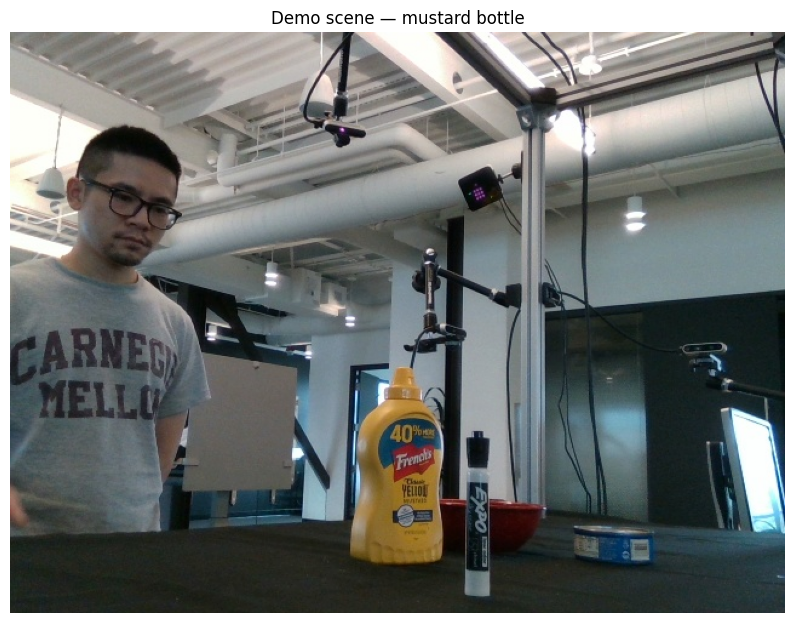

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Image originale de la scène
color = mpimg.imread('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/color.png')

# Pose estimée
pose = np.loadtxt('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/demo_mustard_initial_pose.txt')
K    = np.loadtxt('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/K.txt')

print('Color image shape:', color.shape)
print('Pose:\n', pose)
print('K:\n', K)

plt.figure(figsize=(10, 8))
plt.imshow(color)
plt.title('Demo scene — mustard bottle')
plt.axis('off')
plt.show()

trimesh installed!


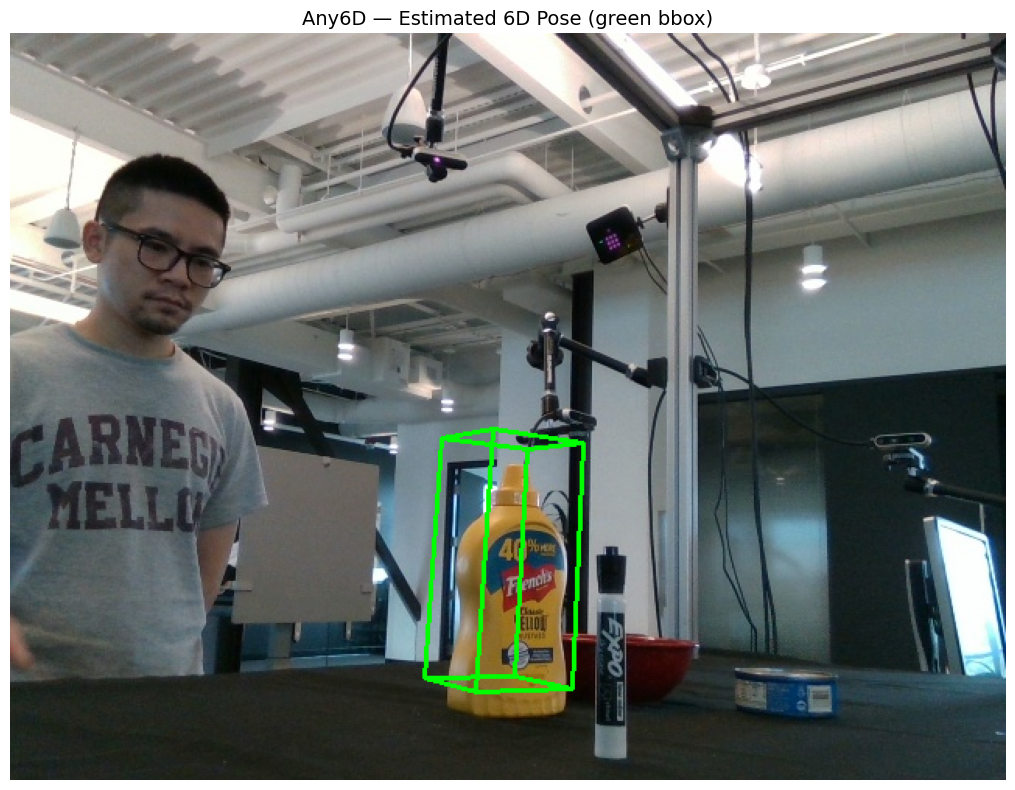

Done!


In [19]:
import subprocess
subprocess.run(['pip', 'install', 'trimesh'], capture_output=True)
print('trimesh installed!')
import trimesh
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load
color = mpimg.imread('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/color.png')
pose  = np.loadtxt('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/demo_mustard_initial_pose.txt')
K     = np.loadtxt('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/K.txt')
mesh  = trimesh.load('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/demo_data/mustard.obj')

# Project 3D bbox corners onto image
b = mesh.bounds
corners = np.array([
    [b[0,0],b[0,1],b[0,2]], [b[1,0],b[0,1],b[0,2]],
    [b[1,0],b[1,1],b[0,2]], [b[0,0],b[1,1],b[0,2]],
    [b[0,0],b[0,1],b[1,2]], [b[1,0],b[0,1],b[1,2]],
    [b[1,0],b[1,1],b[1,2]], [b[0,0],b[1,1],b[1,2]]
])
pts_cam = (pose[:3,:3] @ corners.T + pose[:3,3:]).T
pts_2d  = (K @ pts_cam.T).T
pts_2d  = (pts_2d[:,:2] / pts_2d[:,2:]).astype(int)

# Draw 3D bbox
img = (color * 255).astype(np.uint8).copy() if color.max() <= 1.0 else color.copy()
edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
for i,j in edges:
    cv2.line(img, tuple(pts_2d[i]), tuple(pts_2d[j]), (0,255,0), 2)

# Show
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title('Any6D — Estimated 6D Pose (green bbox)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('/tmp/pose_result.png', dpi=150)
plt.show()
print('Done!')

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Toutes les images de résultats
images = sorted(glob.glob('/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/Any6D/results/demo_mustard/vis_*.png'))
print(f'Found {len(images)} images')
for p in images:
    print(' ', p.split('/')[-1])

Found 8 images
  vis_refiner_stage_1_consider_pose_demo.png
  vis_refiner_stage_2_consider_pose_demo.png
  vis_refiner_stage_3_consider_size.png
  vis_refiner_stage_4_rerun_pose.png
  vis_score_stage_1_consider_pose_demo.png
  vis_score_stage_2_consider_pose_demo.png
  vis_score_stage_3_consider_size.png
  vis_score_stage_4_rerun_pose.png


Loading MiDaS...


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /home/josue_aims_ac_za/.cache/torch/hub/master.zip
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /home/josue_aims_ac_za/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /home/josue_aims_ac_za/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /home/josue_aims_ac_za/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 347MB/s]
Using cache found in /home/josue_aims_ac_za/.cache/torch/hub/intel-isl_MiDaS_master


Running MiDaS...


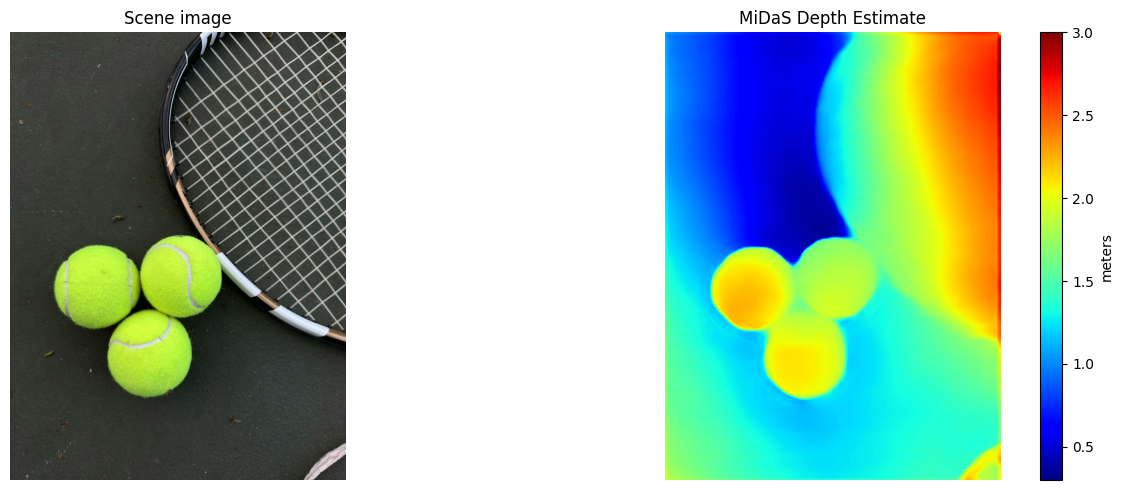

Depth range: 0.30 - 3.00 m
Depth saved to /tmp/yoloe_depth.npy


In [ ]:
# ── Estimate depth with MiDaS ─────────────────────────────────
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load MiDaS model
print('Loading MiDaS...')
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small')
midas.to('cuda')
midas.eval()

transforms = torch.hub.load('intel-isl/MiDaS', 'transforms')
transform = transforms.small_transform

# Load scene image
scene_bgr = cv2.imread(TEST_IMAGE_PATH)
img_rgb   = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
H, W      = img_rgb.shape[:2]

# Run MiDaS
print('Running MiDaS...')
input_batch = transform(img_rgb).to('cuda')

with torch.no_grad():
    depth_pred = midas(input_batch)
    depth_pred = torch.nn.functional.interpolate(
        depth_pred.unsqueeze(1),
        size=(H, W),
        mode='bicubic',
        align_corners=False
    ).squeeze()

depth_map = depth_pred.cpu().numpy()

# Normalize to meters (0.3m to 3m)
d_min, d_max = depth_map.min(), depth_map.max()
depth_m = 0.3 + (depth_map - d_min) / (d_max - d_min) * 2.7



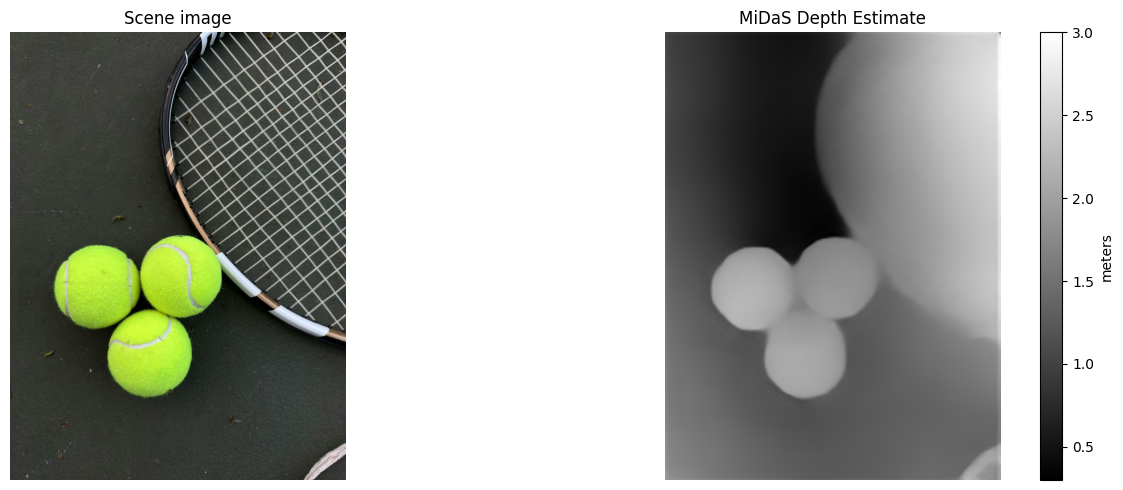

Depth range: 0.30 - 3.00 m
Depth saved to /tmp/yoloe_depth.npy


In [26]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Scene image')
axes[0].axis('off')
im = axes[1].imshow(depth_m, cmap='gray') # ← pour voir facilement
# axes[2].imshow(depth_small, cmap='jet') 
axes[1].set_title('MiDaS Depth Estimate')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='meters')
plt.tight_layout()
plt.show()

print(f'Depth range: {depth_m.min():.2f} - {depth_m.max():.2f} m')

# Save for Any6D
np.save('/tmp/yoloe_depth.npy', depth_m.astype(np.float32))
print('Depth saved to /tmp/yoloe_depth.npy')

In [24]:
import cv2
import numpy as np

TARGET_H, TARGET_W = 480, 640

# Resize
scene_rgb_small = cv2.resize(scene_rgb, (TARGET_W, TARGET_H))
ob_mask_small   = cv2.resize(ob_mask.astype(np.uint8), (TARGET_W, TARGET_H)) > 0
depth_small     = cv2.resize(depth_m, (TARGET_W, TARGET_H))

# Adjust K
scale_x = TARGET_W / W
scale_y = TARGET_H / H
K_small = np.array([
    [W * scale_x,  0,            W/2 * scale_x],
    [0,            W * scale_y,  H/2 * scale_y],
    [0,            0,            1]
], dtype=np.float64)

# Save all
cv2.imwrite('/tmp/yoloe_scene_rgb.png', cv2.cvtColor(scene_rgb_small, cv2.COLOR_RGB2BGR))
np.save('/tmp/yoloe_mask.npy',  ob_mask_small)
np.save('/tmp/yoloe_depth.npy', depth_small.astype(np.float32))
np.save('/tmp/yoloe_K.npy',     K_small)

# Save depth as 16-bit PNG
depth_mm = (depth_small * 1000).astype(np.uint16)
cv2.imwrite('/tmp/yoloe_depth.png', depth_mm)

print(f'Scene:  {scene_rgb_small.shape}')
print(f'Mask:   {ob_mask_small.sum()} pixels')
print(f'Depth:  {depth_small.min():.2f} - {depth_small.max():.2f} m')
print('All saved to /tmp/ !')

Scene:  (480, 640, 3)
Mask:   11877 pixels
Depth:  0.30 - 3.00 m
All saved to /tmp/ !


In [25]:
# Save depth as 16-bit PNG (like a real depth camera)
depth_mm = (depth_small * 1000).astype(np.uint16)  # meters → millimeters
cv2.imwrite('/tmp/yoloe_depth.png', depth_mm)
print(f'Depth PNG saved: {depth_mm.min()} - {depth_mm.max()} mm')

# Also save as npy for Any6D
np.save('/tmp/yoloe_depth.npy', depth_small.astype(np.float32))
print('Depth NPY saved!')

Depth PNG saved: 304 - 2999 mm
Depth NPY saved!


In [ ]:
import shutil

shutil.copy('/tmp/yoloe_depth.png', 
            '/home/josue_aims_ac_za/open-vocabulary-6d-pose-yoloe/images/tennis_res_depth.png')

print('Depth saved to images/tennis_res_depth.png ✅')

Depth saved to images/tennis_res_depth.png ✅
